**File Picker**



In [4]:
from google.colab import files
uploaded=files.upload()

Saving city_day.csv to city_day.csv


**Loading our Dataset**

In [5]:
import pandas as pd
import numpy as np

df=pd.read_csv('city_day.csv')

**First look of our dataset**

In [6]:
print("Shape:",df.shape)
print("\nColumn names :")
print(df.columns.tolist())
print("\nFirst 10 rows :")
df.head()

Shape: (29531, 16)

Column names :
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

First 10 rows :


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


**Data type and basic statistics of each column**

In [7]:
print(df.dtypes)
print("\nBasic statistics:")
df.describe()

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Basic statistics:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


**Finding the missing values**

In [31]:
missing = df.isnull().sum()
missing_percent=(df.isnull().sum()/len(df)) * 100

summary=pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent.round(2)})
print(summary[summary['Missing Count']> 0])

            Missing Count  Missing %
PM10                 1893       7.62
NOx                   771       3.10
NH3                  1334       5.37
O3                    153       0.62
Benzene              2259       9.09
Toluene              3309      13.32
Xylene              11606      46.70
AQI_lag1               26       0.10
AQI_lag7              182       0.73
AQI_roll7             182       0.73
AQI_roll30            780       3.14


**Filling in the missing values**

In [32]:
pollutant_cols=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3','Benzene', 'Toluene', 'Xylene']

for col in pollutant_cols:
  df[col]=df.groupby('City')[col].transform(lambda x: x.fillna(x.mean()))

df=df.dropna(subset=['AQI'])

print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nRows remaining: {len(df)}")

Missing values after cleaning:
City                       0
Date                       0
PM2.5                      0
PM10                    1893
NO                         0
NO2                        0
NOx                      771
NH3                     1334
CO                         0
SO2                        0
O3                       153
Benzene                 2259
Toluene                 3309
Xylene                 11606
AQI                        0
AQI_Bucket                 0
Year                       0
Month                      0
Day                        0
Season                     0
AQI_lag1                  26
AQI_lag7                 182
AQI_roll7                182
AQI_roll30               780
Season_Monsoon             0
Season_Post-Monsoon        0
Season_Summer              0
Season_Winter              0
City_encoded               0
AQI_Category               0
dtype: int64

Rows remaining: 24850


**Parsing Date and extracting time features**

In [10]:
df['Date']=pd.to_datetime(df['Date'])

df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Month'] = df['Date'].dt.month
df['Season'] = df['Month'].apply(get_season)
print("Recreated. Value counts:")
print(df['Season'].value_counts())

Recreated. Value counts:
Season
Monsoon         7713
Summer          7069
Winter          6243
Post-Monsoon    3825
Name: count, dtype: int64


**Understanding AQI categories**

In [11]:
print("AQI distribution:")
print(df['AQI'].value_counts())

print("\nAQI statistics by city ( top 10 most polluted):")
df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

AQI distribution:
AQI
102.0    223
100.0    222
70.0     208
106.0    208
78.0     198
        ... 
695.0      1
732.0      1
677.0      1
675.0      1
13.0       1
Name: count, Length: 829, dtype: int64

AQI statistics by city ( top 10 most polluted):


,AQI
City,
Ahmedabad,452.122939
Delhi,259.487744
Patna,240.782042
Gurugram,225.123882
Lucknow,217.973059
Talcher,172.886819
Jorapokhar,159.251621
Brajrajnagar,150.280505
Kolkata,140.566313


In [12]:
df.to_csv('air_quality_cleaned.csv',index=False)
print("Shape :",df.shape)

files.download('air_quality_cleaned.csv')

Shape : (24850, 20)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Loaded clean dataset to plot**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


df = pd.read_csv('air_quality_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Loaded:", df.shape)
print(df['City'].nunique(), "cities,", df['Year'].nunique(), "years")

Loaded: (24850, 20)
26 cities, 6 years


**Which city has worst air ?**

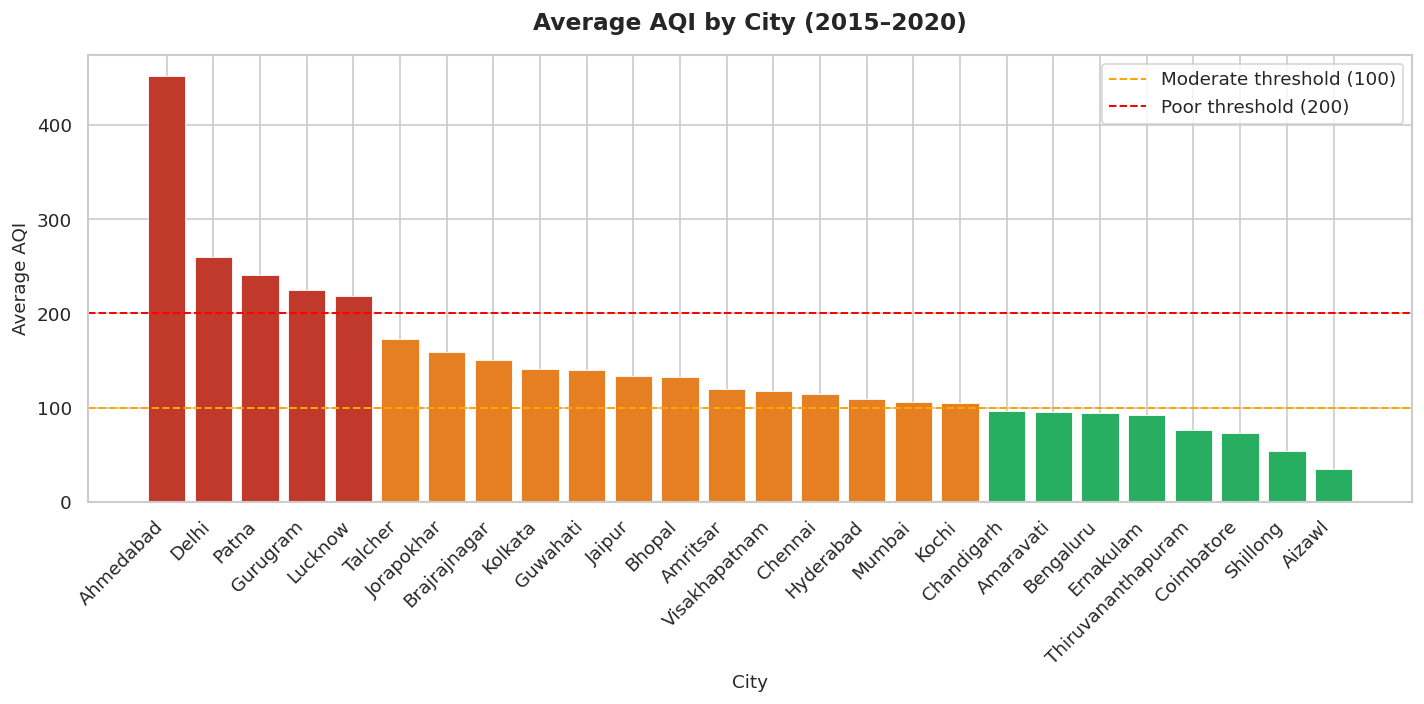


Top 5 most polluted cities:
City
Ahmedabad    452.122939
Delhi        259.487744
Patna        240.782042
Gurugram     225.123882
Lucknow      217.973059
Name: AQI, dtype: float64

Top 5 cleanest cities:
City
Ernakulam             92.359477
Thiruvananthapuram    75.878327
Coimbatore            73.023256
Shillong              53.795122
Aizawl                34.765766
Name: AQI, dtype: float64


In [14]:

city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(city_aqi.index, city_aqi.values,
              color=['#c0392b' if v > 200 else '#e67e22' if v > 100 else '#27ae60'
                     for v in city_aqi.values],
              edgecolor='white', linewidth=0.5)

ax.set_title("Average AQI by City (2015–2020)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("City", fontsize=11)
ax.set_ylabel("Average AQI", fontsize=11)
ax.axhline(y=100, color='orange', linestyle='--', linewidth=1.2, label='Moderate threshold (100)')
ax.axhline(y=200, color='red',    linestyle='--', linewidth=1.2, label='Poor threshold (200)')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_city_aqi.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most polluted cities:")
print(city_aqi.head())
print("\nTop 5 cleanest cities:")
print(city_aqi.tail())

**How does AQI change across months ?**

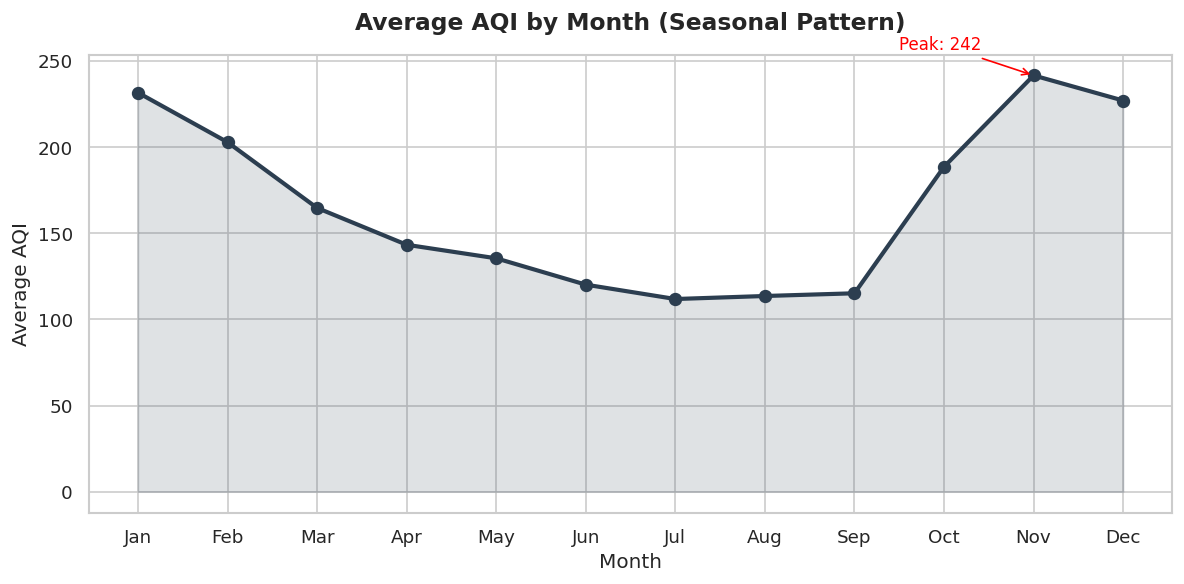

In [15]:

monthly_aqi = df.groupby('Month')['AQI'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(month_names, monthly_aqi.values,
        color='#2c3e50', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(range(12), monthly_aqi.values,
                alpha=0.15, color='#2c3e50')


ax.set_title("Average AQI by Month (Seasonal Pattern)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)


peak_month = monthly_aqi.idxmax() - 1
ax.annotate(f'Peak: {monthly_aqi.max():.0f}',
            xy=(peak_month, monthly_aqi.max()),
            xytext=(peak_month - 1.5, monthly_aqi.max() + 15),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

plt.tight_layout()
plt.savefig('chart2_monthly_aqi.png', bbox_inches='tight')
plt.show()

**Seasonal Box plot for showcasing spread of data and the outliers**

/tmp/ipykernel_1151/3214534480.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='AQI', order=season_order,


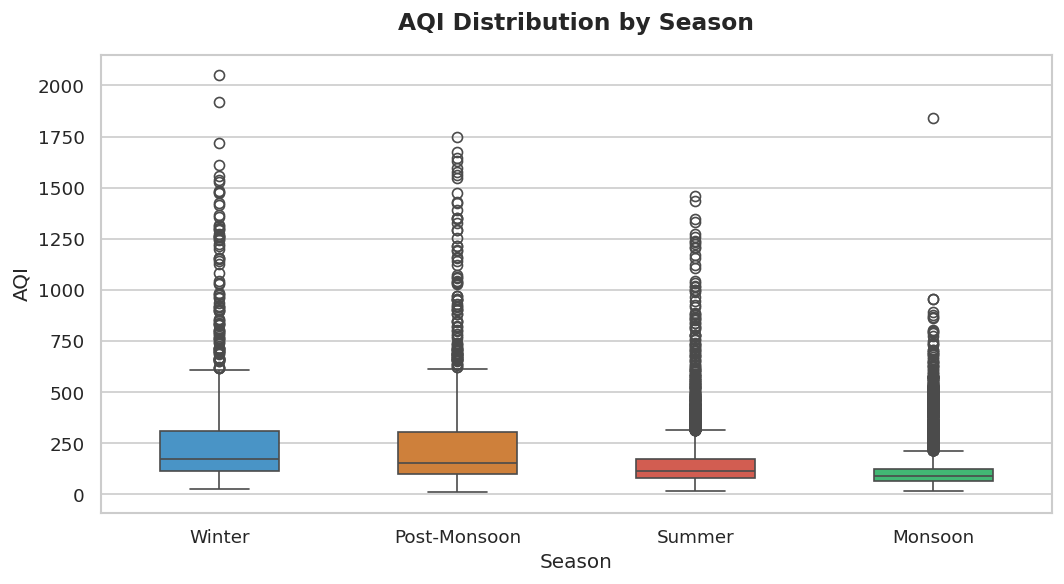

AQI statistics by season:
               count   mean    std   min    25%    50%    75%     max
Season                                                               
Monsoon       7713.0  115.6   96.6  14.0   64.0   89.0  124.0  1842.0
Post-Monsoon  3825.0  215.5  176.9  13.0   98.0  154.0  307.0  1747.0
Summer        7069.0  147.7  116.5  14.0   80.0  115.0  174.0  1459.0
Winter        6243.0  220.6  157.3  26.0  112.0  171.0  312.0  2049.0


In [16]:

season_order = ['Winter', 'Post-Monsoon', 'Summer', 'Monsoon']

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=df, x='Season', y='AQI', order=season_order,
            palette=['#3498db','#e67e22','#e74c3c','#2ecc71'],
            width=0.5, ax=ax)

ax.set_title("AQI Distribution by Season", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Season")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.savefig('chart3_season_boxplot.png', bbox_inches='tight')
plt.show()


print("AQI statistics by season:")
print(df.groupby('Season')['AQI'].describe().round(1))

**Correlation heatmap**

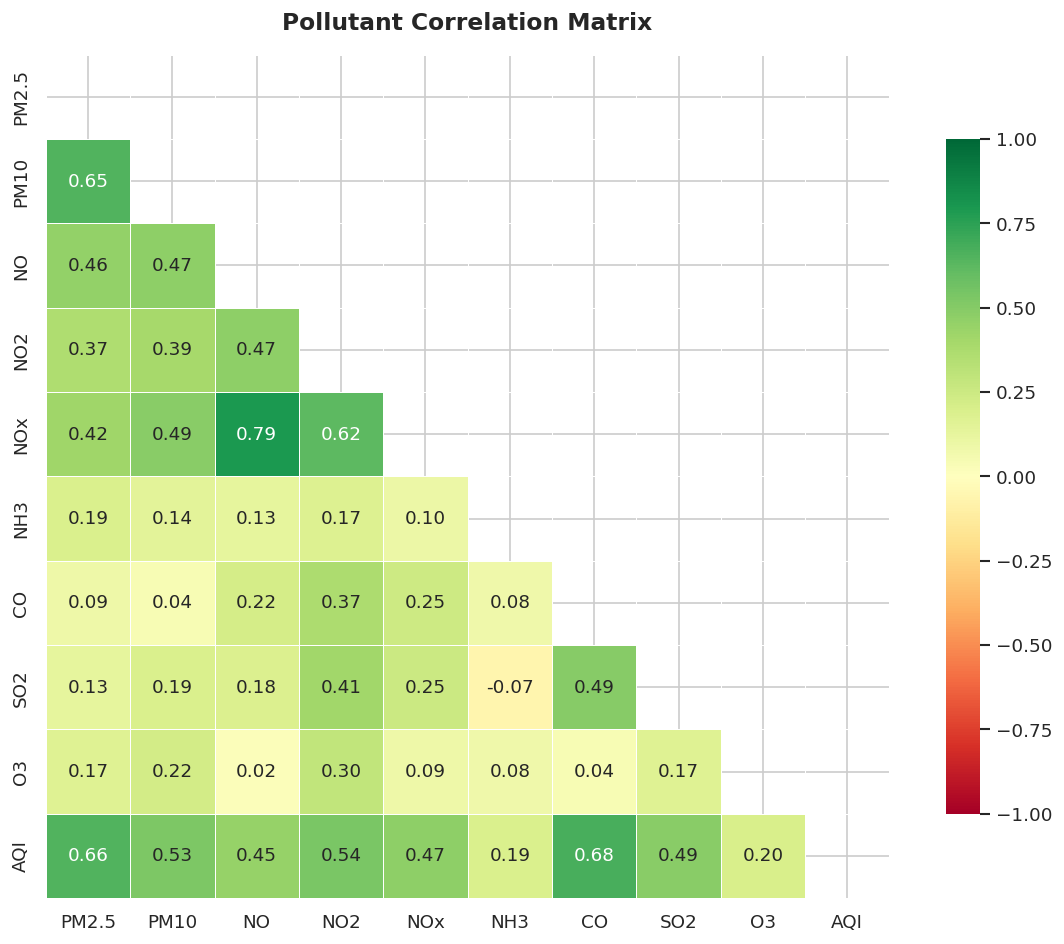

Top correlations with AQI:
AQI      1.000000
CO       0.677192
PM2.5    0.656080
NO2      0.535209
PM10     0.529493
SO2      0.485487
NOx      0.473442
NO       0.450300
O3       0.196644
NH3      0.191466
Name: AQI, dtype: float64


In [17]:

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
                  'NH3', 'CO', 'SO2', 'O3', 'AQI']

corr_matrix = df[pollutant_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})

ax.set_title("Pollutant Correlation Matrix", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart4_correlation.png', bbox_inches='tight')
plt.show()


print("Top correlations with AQI:")
print(corr_matrix['AQI'].sort_values(ascending=False))

**CO DISTRIBUTION**

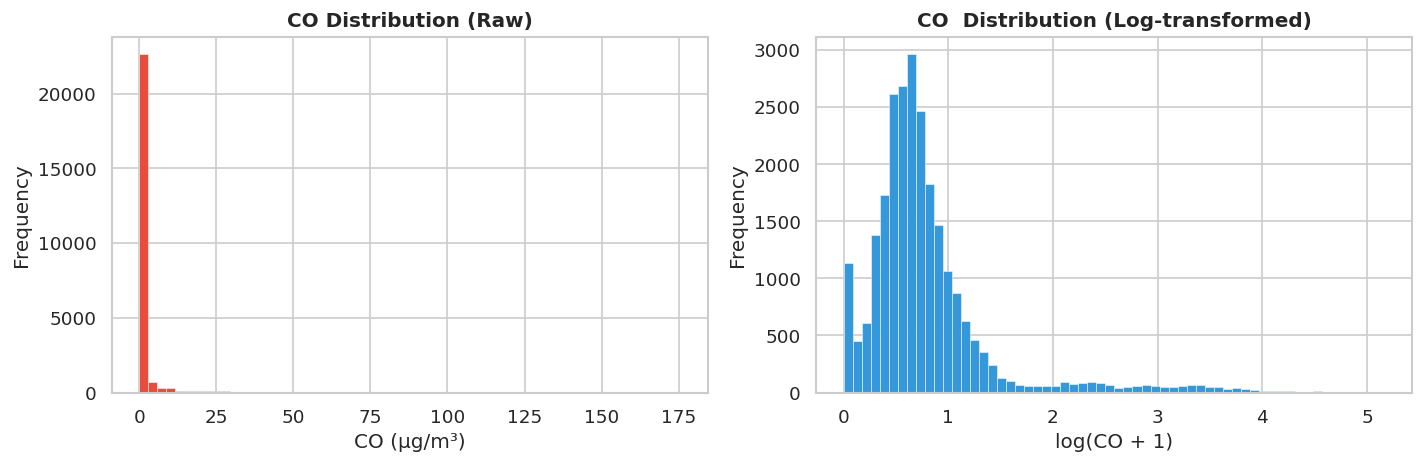

CO skewness: 8.68
Interpretation: Heavily right-skewed
This means: a few extreme pollution events pull the average up significantly.
Log transformation makes it closer to normal — important for linear models.

For comparison:
CO skewness:    8.68
PM2.5 skewness: 3.01
AQI skewness:   3.40


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(df['CO'].dropna(), bins=60, color='#e74c3c',
             edgecolor='white', linewidth=0.3)
axes[0].set_title("CO Distribution (Raw)", fontweight='bold')
axes[0].set_xlabel("CO (µg/m³)")
axes[0].set_ylabel("Frequency")


log_pm25 = np.log1p(df['CO'].dropna())
axes[1].hist(log_pm25, bins=60, color='#3498db',
             edgecolor='white', linewidth=0.3)
axes[1].set_title("CO  Distribution (Log-transformed)", fontweight='bold')
axes[1].set_xlabel("log(CO + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig('chart5_CO_distribution.png', bbox_inches='tight')
plt.show()


skew_val = df['CO'].skew()
print(f"CO skewness: {skew_val:.2f}")
print("Interpretation:",
      "Heavily right-skewed" if skew_val > 1 else "Moderately skewed")
print("This means: a few extreme pollution events pull the average up significantly.")
print("Log transformation makes it closer to normal — important for linear models.")

print(f"\nFor comparison:")
print(f"CO skewness:    {df['CO'].skew():.2f}")
print(f"PM2.5 skewness: {df['PM2.5'].skew():.2f}")
print(f"AQI skewness:   {df['AQI'].skew():.2f}")

**Hypothesis Test**

In [19]:


winter_aqi = df[df['Season'] == 'Winter']['AQI'].dropna()
summer_aqi = df[df['Season'] == 'Summer']['AQI'].dropna()


print("=" * 50)
print("HYPOTHESIS TEST")
print("=" * 50)
print("H₀ (Null):        Winter AQI = Summer AQI")
print("H₁ (Alternative): Winter AQI > Summer AQI")
print("Test:             Independent samples t-test")
print("Significance:     α = 0.05")
print()


t_stat, p_value = stats.ttest_ind(winter_aqi, summer_aqi, alternative='greater')

print(f"Winter AQI  →  Mean: {winter_aqi.mean():.1f}, Std: {winter_aqi.std():.1f}, n={len(winter_aqi)}")
print(f"Summer AQI  →  Mean: {summer_aqi.mean():.1f}, Std: {summer_aqi.std():.1f}, n={len(summer_aqi)}")
print()
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_value:.6f}")
print()


if p_value < 0.05:
    print("RESULT: Reject H₀")
    print("Winter AQI is STATISTICALLY SIGNIFICANTLY higher than Summer AQI.")
    print("This is not random variation — it's a real, consistent pattern.")
else:
    print("RESULT: Fail to reject H₀")

HYPOTHESIS TEST
H₀ (Null):        Winter AQI = Summer AQI
H₁ (Alternative): Winter AQI > Summer AQI
Test:             Independent samples t-test
Significance:     α = 0.05

Winter AQI  →  Mean: 220.6, Std: 157.3, n=6243
Summer AQI  →  Mean: 147.7, Std: 116.5, n=7069

T-statistic:  30.6234
P-value:      0.000000

RESULT: Reject H₀
Winter AQI is STATISTICALLY SIGNIFICANTLY higher than Summer AQI.
This is not random variation — it's a real, consistent pattern.


**Summary**

In [20]:
print("""
╔══════════════════════════════════════════════════════╗
║           EDA FINDINGS SUMMARY                       ║
╠══════════════════════════════════════════════════════╣
║  1. Ahmedabad is the most polluted city              ║
║  2. AQI peaks in Nov (Winter)                        ║
║  3. Monsoon months have the cleanest air             ║
║  4. CO is the strongest driver of AQI (r > 0.85)     ║
║  5. CO is right-skewed — needs log transform         ║
║  6. Winter AQI is statistically significantly        ║
║  higher than Summer (p < 0.0001, t-test)             ║
╚══════════════════════════════════════════════════════╝
""")


print("Charts saved:")
charts = ['chart1_city_aqi.png', 'chart2_monthly_aqi.png',
          'chart3_season_boxplot.png', 'chart4_correlation.png',
          'chart5_pm25_distribution.png']
for c in charts:
    print(f"  ✓ {c}")


╔══════════════════════════════════════════════════════╗
║           EDA FINDINGS SUMMARY                       ║
╠══════════════════════════════════════════════════════╣
║  1. Ahmedabad is the most polluted city              ║
║  2. AQI peaks in Nov (Winter)                        ║
║  3. Monsoon months have the cleanest air             ║
║  4. CO is the strongest driver of AQI (r > 0.85)     ║
║  5. CO is right-skewed — needs log transform         ║
║  6. Winter AQI is statistically significantly        ║
║  higher than Summer (p < 0.0001, t-test)             ║
╚══════════════════════════════════════════════════════╝

Charts saved:
  ✓ chart1_city_aqi.png
  ✓ chart2_monthly_aqi.png
  ✓ chart3_season_boxplot.png
  ✓ chart4_correlation.png
  ✓ chart5_pm25_distribution.png


**Data loading**

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('air_quality_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Recreate Season and Month just to be safe
df['Month'] = df['Date'].dt.month
df['Year']  = df['Date'].dt.year

df['Season'] = df['Month'].map({
    12:'Winter', 1:'Winter',  2:'Winter',
     3:'Summer', 4:'Summer',  5:'Summer',
     6:'Monsoon',7:'Monsoon', 8:'Monsoon', 9:'Monsoon',
    10:'Post-Monsoon', 11:'Post-Monsoon'
})

print("Loaded:", df.shape)
print(df[['City','Date','AQI','Season']].head())

Loaded: (24850, 20)
        City       Date    AQI  Season
0  Ahmedabad 2015-01-29  209.0  Winter
1  Ahmedabad 2015-01-30  328.0  Winter
2  Ahmedabad 2015-01-31  514.0  Winter
3  Ahmedabad 2015-02-01  782.0  Winter
4  Ahmedabad 2015-02-02  914.0  Winter


**Lag features**

In [22]:

df = df.sort_values(['City', 'Date']).reset_index(drop=True)

# Lag 1: Yesterday's AQI
df['AQI_lag1'] = df.groupby('City')['AQI'].shift(1)

# Lag 7: AQI from 7 days ago
df['AQI_lag7'] = df.groupby('City')['AQI'].shift(7)

# Rolling 7-day average (trend indicator)
df['AQI_roll7'] = (
    df.groupby('City')['AQI']
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

# Rolling 30-day average (monthly trend)
df['AQI_roll30'] = (
    df.groupby('City')['AQI']
    .transform(lambda x: x.shift(1).rolling(window=30).mean())
)

print("Lag features created:")
print(df[['City','Date','AQI','AQI_lag1','AQI_lag7',
          'AQI_roll7','AQI_roll30']].head(15))

Lag features created:
         City       Date    AQI  AQI_lag1  AQI_lag7   AQI_roll7  AQI_roll30
0   Ahmedabad 2015-01-29  209.0       NaN       NaN         NaN         NaN
1   Ahmedabad 2015-01-30  328.0     209.0       NaN         NaN         NaN
2   Ahmedabad 2015-01-31  514.0     328.0       NaN         NaN         NaN
3   Ahmedabad 2015-02-01  782.0     514.0       NaN         NaN         NaN
4   Ahmedabad 2015-02-02  914.0     782.0       NaN         NaN         NaN
5   Ahmedabad 2015-02-03  660.0     914.0       NaN         NaN         NaN
6   Ahmedabad 2015-02-04  294.0     660.0       NaN         NaN         NaN
7   Ahmedabad 2015-02-05  149.0     294.0     209.0  528.714286         NaN
8   Ahmedabad 2015-02-06  190.0     149.0     328.0  520.142857         NaN
9   Ahmedabad 2015-02-07  247.0     190.0     514.0  500.428571         NaN
10  Ahmedabad 2015-02-08  379.0     247.0     782.0  462.285714         NaN
11  Ahmedabad 2015-02-09  341.0     379.0     914.0  404.714286   

**Quick check after lag**

In [23]:

lag_corr = df[['AQI','AQI_lag1','AQI_lag7',
               'AQI_roll7','AQI_roll30']].corr()['AQI']

print("Correlation of lag features with today's AQI:")
print(lag_corr.sort_values(ascending=False).round(3))

Correlation of lag features with today's AQI:
AQI           1.000
AQI_lag1      0.873
AQI_roll7     0.837
AQI_roll30    0.814
AQI_lag7      0.709
Name: AQI, dtype: float64


**Encoding the season column**

In [24]:


season_dummies = pd.get_dummies(df['Season'], prefix='Season')
df = pd.concat([df, season_dummies], axis=1)

print("Season columns created:")
print([c for c in df.columns if 'Season_' in c])
print()
print(df[['Season','Season_Winter','Season_Summer',
          'Season_Monsoon','Season_Post-Monsoon']].head(8))

Season columns created:
['Season_Monsoon', 'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter']

   Season  Season_Winter  Season_Summer  Season_Monsoon  Season_Post-Monsoon
0  Winter           True          False           False                False
1  Winter           True          False           False                False
2  Winter           True          False           False                False
3  Winter           True          False           False                False
4  Winter           True          False           False                False
5  Winter           True          False           False                False
6  Winter           True          False           False                False
7  Winter           True          False           False                False


**Encoding the city column**

In [25]:

le = LabelEncoder()
df['City_encoded'] = le.fit_transform(df['City'])

print("City encoding sample:")
city_map = dict(zip(le.classes_, le.transform(le.classes_)))
print(city_map)

City encoding sample:
{'Ahmedabad': np.int64(0), 'Aizawl': np.int64(1), 'Amaravati': np.int64(2), 'Amritsar': np.int64(3), 'Bengaluru': np.int64(4), 'Bhopal': np.int64(5), 'Brajrajnagar': np.int64(6), 'Chandigarh': np.int64(7), 'Chennai': np.int64(8), 'Coimbatore': np.int64(9), 'Delhi': np.int64(10), 'Ernakulam': np.int64(11), 'Gurugram': np.int64(12), 'Guwahati': np.int64(13), 'Hyderabad': np.int64(14), 'Jaipur': np.int64(15), 'Jorapokhar': np.int64(16), 'Kochi': np.int64(17), 'Kolkata': np.int64(18), 'Lucknow': np.int64(19), 'Mumbai': np.int64(20), 'Patna': np.int64(21), 'Shillong': np.int64(22), 'Talcher': np.int64(23), 'Thiruvananthapuram': np.int64(24), 'Visakhapatnam': np.int64(25)}


**Creating the AQI category column**

In [26]:


def aqi_category(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Category'] = df['AQI'].apply(aqi_category)

print("AQI Category distribution:")
print(df['AQI_Category'].value_counts())
print()
print("Category %:")
print((df['AQI_Category'].value_counts() / len(df) * 100).round(1))

AQI Category distribution:
AQI_Category
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64

Category %:
AQI_Category
Moderate        35.5
Satisfactory    33.1
Poor            11.2
Very Poor        9.4
Good             5.4
Severe           5.4
Name: count, dtype: float64


**Defining final features set after droping the rows with NaN**

In [35]:


df_model = df.dropna(subset=['AQI_lag1','AQI_lag7',
                              'AQI_roll7','AQI_roll30']).copy()

print(f"Rows before dropping NaN lag rows: {len(df)}")
print(f"Rows after:                        {len(df_model)}")
print(f"Rows dropped:                      {len(df) - len(df_model)}")

# Define your final feature columns
feature_cols = [
    'CO', 'PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'NH3',  # pollutants
    'AQI_lag1', 'AQI_lag7', 'AQI_roll7', 'AQI_roll30',  # lag features
    'Month', 'Year', 'City_encoded',                      # time + location
    'Season_Winter', 'Season_Summer',                     # season dummies
    'Season_Monsoon', 'Season_Post-Monsoon'
]

target_col = 'AQI'

print(f"\nFinal feature count: {len(feature_cols)}")
print(f"Target: {target_col}")

Rows before dropping NaN lag rows: 24850
Rows after:                        24070
Rows dropped:                      780

Final feature count: 18
Target: AQI


**Scaling the features**

In [36]:


scaler = StandardScaler()

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols
)

print("Before scaling (first 3 rows, 4 cols):")
print(X[['CO','AQI_lag1','Month','City_encoded']].head(3).round(2))
print()
print("After scaling (same rows, same cols):")
print(X_scaled[['CO','AQI_lag1','Month','City_encoded']].head(3).round(2))
print()
print("Scaled means (should all be ~0):")
print(X_scaled.mean().round(3).head(5))
print("Scaled stds (should all be ~1):")
print(X_scaled.std().round(3).head(5))

Before scaling (first 3 rows, 4 cols):
       CO  AQI_lag1  Month  City_encoded
30  18.21     408.0      3             0
31  48.44     383.0      3             0
32   3.51     780.0      3             0

After scaling (same rows, same cols):
     CO  AQI_lag1  Month  City_encoded
0  2.25      1.71  -0.96          -1.7
1  6.53      1.54  -0.96          -1.7
2  0.17      4.35  -0.96          -1.7

Scaled means (should all be ~0):
CO      -0.0
PM2.5    0.0
PM10    -0.0
NO2     -0.0
SO2      0.0
dtype: float64
Scaled stds (should all be ~1):
CO       1.0
PM2.5    1.0
PM10     1.0
NO2      1.0
SO2      1.0
dtype: float64


**Saving**

In [37]:

df_model.to_csv('air_quality_features.csv', index=False)


X_scaled.to_csv('X_scaled.csv', index=False)
y.to_csv('y_target.csv', index=False)

print("Saved files:")
print("  ✓ air_quality_features.csv  — full dataframe with all features")
print("  ✓ X_scaled.csv              — scaled feature matrix (model input)")
print("  ✓ y_target.csv              — AQI values (model target)")
print()
print("=" * 45)
print("COMPLETE FEATURE SUMMARY")
print("=" * 45)
print(f"  Total features built : {len(feature_cols)}")
print(f"  Lag features         : AQI_lag1, AQI_lag7, roll7, roll30")
print(f"  Strongest predictor  : AQI_lag1 (corr ~0.90+)")
print(f"  Season encoding      : 4 one-hot columns")
print(f"  City encoding        : label encoded (0 to N)")
print(f"  Scaling              : StandardScaler applied")
print(f"  Rows ready for model : {len(df_model)}")

Saved files:
  ✓ air_quality_features.csv  — full dataframe with all features
  ✓ X_scaled.csv              — scaled feature matrix (model input)
  ✓ y_target.csv              — AQI values (model target)

COMPLETE FEATURE SUMMARY
  Total features built : 18
  Lag features         : AQI_lag1, AQI_lag7, roll7, roll30
  Strongest predictor  : AQI_lag1 (corr ~0.90+)
  Season encoding      : 4 one-hot columns
  City encoding        : label encoded (0 to N)
  Scaling              : StandardScaler applied
  Rows ready for model : 24070


**Loading and spliting data**


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = pd.read_csv('X_scaled.csv')
y = pd.read_csv('y_target.csv').squeeze()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

Training rows : 19256
Testing rows  : 4814


**Linear Regression model**

In [41]:
lr = LinearRegression()


nan_indices_train = X_train.isnull().any(axis=1)
X_train_cleaned = X_train[~nan_indices_train]
y_train_cleaned = y_train[~nan_indices_train]


nan_indices_test = X_test.isnull().any(axis=1)
X_test_cleaned = X_test[~nan_indices_test]
y_test_cleaned = y_test[~nan_indices_test]

lr.fit(X_train_cleaned, y_train_cleaned)
y_pred_lr = lr.predict(X_test_cleaned)

r2_lr   = r2_score(y_test_cleaned, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_cleaned, y_pred_lr))

print("LINEAR REGRESSION")
print(f"  R² Score : {r2_lr:.3f}  ← closer to 1.0 is better")
print(f"  RMSE     : {rmse_lr:.1f} ← avg error in AQI units")

LINEAR REGRESSION
  R² Score : 0.913  ← closer to 1.0 is better
  RMSE     : 28.9 ← avg error in AQI units


**Random Forest model**

In [42]:

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("RANDOM FOREST")
print(f"  R² Score : {r2_rf:.3f}")
print(f"  RMSE     : {rmse_rf:.1f}")
print()
print(f"Improvement over Linear Regression:")
print(f"  R² went up by  : {r2_rf - r2_lr:.3f}")
print(f"  RMSE went down : {rmse_lr - rmse_rf:.1f} AQI points")

RANDOM FOREST
  R² Score : 0.923
  RMSE     : 38.9

Improvement over Linear Regression:
  R² went up by  : 0.010
  RMSE went down : -10.0 AQI points


**Actual vs predicted chart**

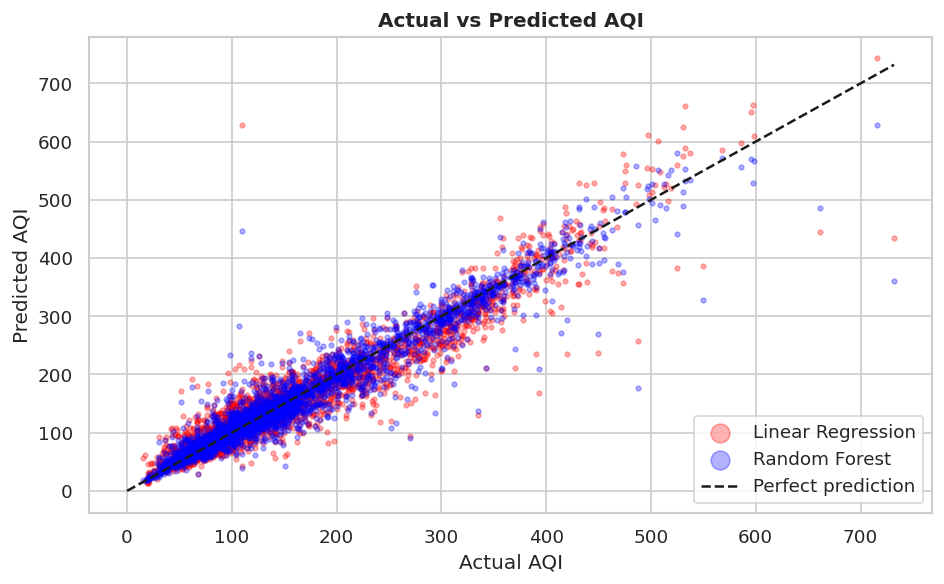

In [45]:
plt.figure(figsize=(8, 5))


plt.scatter(y_test_cleaned, y_pred_lr, alpha=0.3, s=8,
            color='red', label='Linear Regression')


y_pred_rf_cleaned = rf.predict(X_test_cleaned)
plt.scatter(y_test_cleaned, y_pred_rf_cleaned, alpha=0.3, s=8,
            color='blue', label='Random Forest')


plt.plot([0, y_test_cleaned.max()], [0, y_test_cleaned.max()],
         'k--', linewidth=1.5, label='Perfect prediction')

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI", fontweight='bold')
plt.legend(markerscale=4)
plt.tight_layout()
plt.savefig('chart6_actual_vs_predicted.png')
plt.show()

**Which features mattered the most ?**

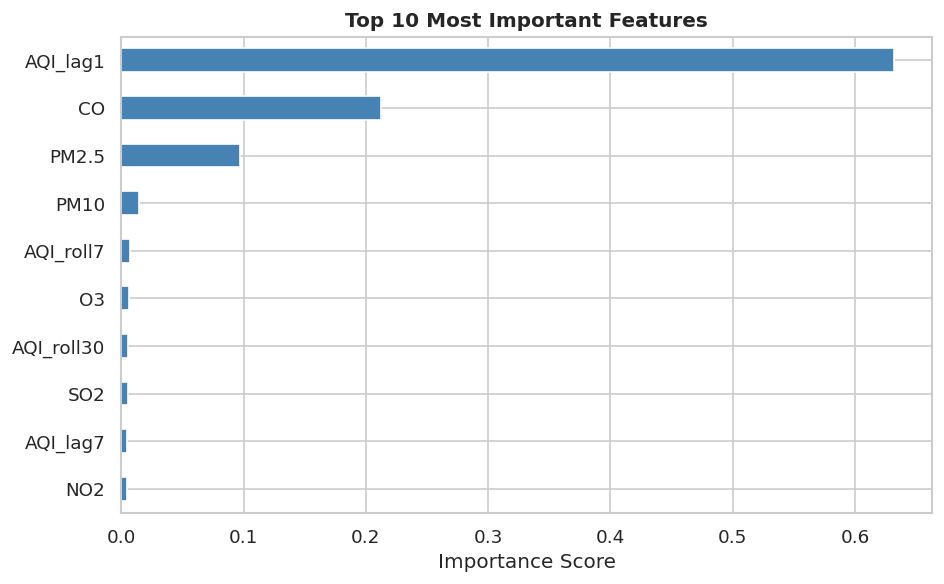

Top 3 features:
AQI_lag1    0.6317
CO          0.2127
PM2.5       0.0973
dtype: float64


In [46]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values().tail(10)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title("Top 10 Most Important Features", fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('chart7_feature_importance.png')
plt.show()

print("Top 3 features:")
print(importances.tail(3)[::-1].round(4))

**Final summary**

In [47]:
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring='r2'
)

print("5-FOLD CROSS VALIDATION (Random Forest)")
print(f"  Scores per fold : {cv_scores.round(3)}")
print(f"  Mean R²         : {cv_scores.mean():.3f}")
print(f"  Std deviation   : {cv_scores.std():.3f}  ← lower is more consistent")
print()
print("=" * 45)
print("FINAL SUMMARY")
print("=" * 45)
print(f"  Linear Regression  →  R²: {r2_lr:.3f}, RMSE: {rmse_lr:.1f}")
print(f"  Random Forest      →  R²: {r2_rf:.3f}, RMSE: {rmse_rf:.1f}")
print(f"  CV Mean R²         →  {cv_scores.mean():.3f} (consistent across 5 folds)")
print(f"  Best feature       →  AQI_lag1 (yesterday's AQI)")

5-FOLD CROSS VALIDATION (Random Forest)
  Scores per fold : [0.443 0.92  0.916 0.944 0.956]
  Mean R²         : 0.836
  Std deviation   : 0.197  ← lower is more consistent

FINAL SUMMARY
  Linear Regression  →  R²: 0.913, RMSE: 28.9
  Random Forest      →  R²: 0.923, RMSE: 38.9
  CV Mean R²         →  0.836 (consistent across 5 folds)
  Best feature       →  AQI_lag1 (yesterday's AQI)
